In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
result = pd.read_csv("Temperature_Predictions.csv")
result.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day,day_of_week,quarter,Predicted_Temperature
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,1,6,1,24.900640
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,2,0,1,13.849077
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,3,1,1,13.345381
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,4,2,1,14.958087
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,5,3,1,18.290299


In [2]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   114 non-null    object 
 1   meantemp               114 non-null    float64
 2   humidity               114 non-null    float64
 3   wind_speed             114 non-null    float64
 4   meanpressure           114 non-null    float64
 5   year                   114 non-null    int64  
 6   month                  114 non-null    int64  
 7   day                    114 non-null    int64  
 8   day_of_week            114 non-null    int64  
 9   quarter                114 non-null    int64  
 10  Predicted_Temperature  114 non-null    float64
dtypes: float64(5), int64(5), object(1)
memory usage: 9.9+ KB


In [3]:
mae = mean_absolute_error(
    result["meantemp"],
    result["Predicted_Temperature"]
)
rmse = np.sqrt(
    mean_squared_error(
        result["meantemp"],
        result["Predicted_Temperature"]
    )
)
r2 = r2_score(
    result["meantemp"],
    result["Predicted_Temperature"]
)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

MAE : 2.6
RMSE: 3.29
R² Score: 0.73


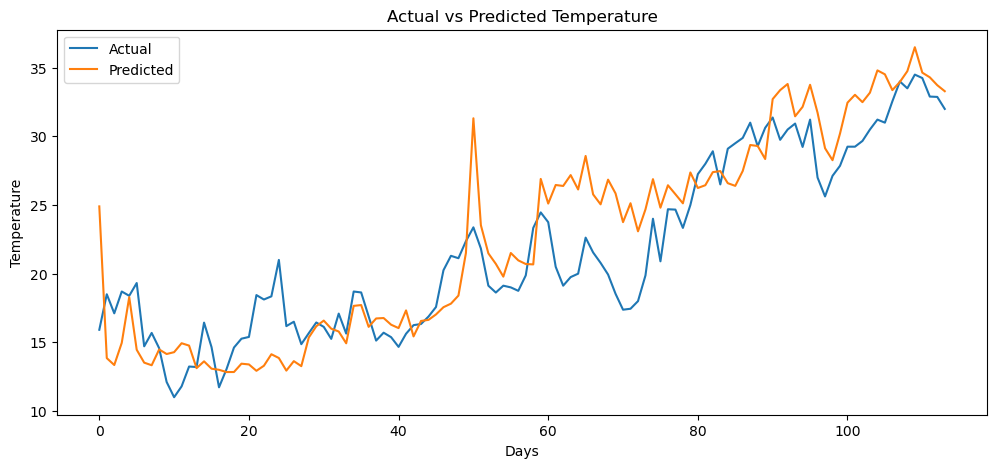

In [4]:
plt.figure(figsize=(12,5))

plt.plot(result["meantemp"], label="Actual")
plt.plot(result["Predicted_Temperature"], label="Predicted")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.legend()

plt.show()

In [5]:
result["Error"] = (
    result["meantemp"] -
    result["Predicted_Temperature"]
)
result.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day,day_of_week,quarter,Predicted_Temperature,Error
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,1,6,1,24.900640,-8.987597
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,2,0,1,13.849077,4.650923
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,3,1,1,13.345381,3.765730
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,4,2,1,14.958087,3.741913
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,5,3,1,18.290299,0.098589


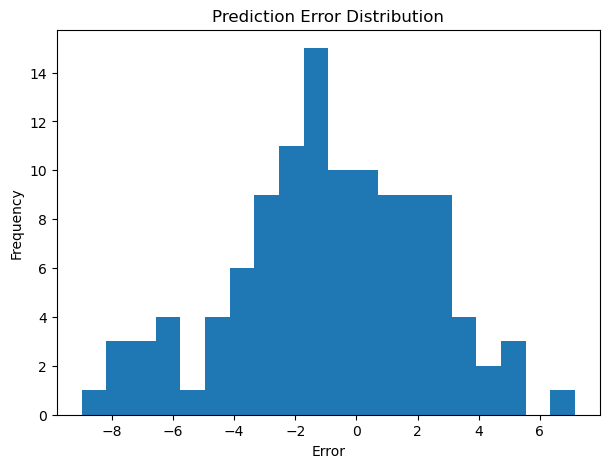

In [6]:
plt.figure(figsize=(7,5))
plt.hist(result["Error"], bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [7]:
result.to_csv(
    "Delhi_Climate_Final_Result.csv",
    index=False
)